# 🏥 Gemma 1.1 7B IT Medical Fine-Tuning (GERÇEK EĞİTİM)

Bu notebook **TAMAMEN GERÇEK** training yapar - hiçbir varsayım yok!

In [1]:
%%capture
# Gerekli kütüphaneleri kur
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [2]:
# Kütüphaneleri import et
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import gc

print("✅ Kütüphaneler yüklendi!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Kütüphaneler yüklendi!
PyTorch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4
GPU Memory: 14.74 GB


In [3]:
# GPU belleğini temizle
torch.cuda.empty_cache()
gc.collect()

print("🧹 GPU belleği temizlendi!")
if torch.cuda.is_available():
    print(f"💾 Boş GPU Belleği: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

🧹 GPU belleği temizlendi!
💾 Boş GPU Belleği: 14.64 GB


In [4]:
# Model Konfigürasyonu
max_seq_length = 1024
dtype = None
load_in_4bit = True

print("🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-1.1-7b-it-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)

print("✅ Model başarıyla yüklendi!")
print(f"Model: Gemma-1.1-7B-IT (4-bit)")
print(f"Max Sequence Length: {max_seq_length}")

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU Memory Allocated: {allocated:.2f} GB")
    print(f"GPU Memory Reserved: {reserved:.2f} GB")

🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)
==((====))==  Unsloth 2025.12.8: Fast Gemma patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Model başarıyla yüklendi!
Model: Gemma-1.1-7B-IT (4-bit)
Max Sequence Length: 1024
GPU Memory Allocated: 5.21 GB
GPU Memory Reserved: 5.22 GB


In [5]:
# LoRA Ayarları
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("✅ LoRA konfigürasyonu tamamlandı!")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"📊 Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

Unsloth 2025.12.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ LoRA konfigürasyonu tamamlandı!
📊 Eğitilebilir Parametreler: 50,003,968 (1.06%)


In [6]:
# Dataset Yükleme
print("📂 Dataset yükleniyor...")

dataset = load_dataset("Shekswess/medical_llama3_instruct_dataset_short", split="train")
print(f"✅ Dataset yüklendi: {len(dataset)} örnek")

dataset = dataset.select(range(50))
print(f"🎯 İlk 50 örnek seçildi: {len(dataset)} örnek")

print(f"\n🔍 Dataset Sütunları: {dataset.column_names}")
print(f"\n📝 İlk Örnek:")
print(f"Instruction: {dataset[0]['instruction'][:100]}...")
print(f"Input: {dataset[0]['input'][:100]}...")
print(f"Output: {dataset[0]['output'][:100]}...")

print(f"\n📊 Dataset İstatistikleri:")
print(f"- Toplam Örnek: {len(dataset)}")
print(f"- Alan: Tıbbi Soru-Cevap")

📂 Dataset yükleniyor...
✅ Dataset yüklendi: 2000 örnek
🎯 İlk 50 örnek seçildi: 50 örnek

🔍 Dataset Sütunları: ['output', 'input', 'instruction', 'prompt']

📝 İlk Örnek:
Instruction: Answer the question truthfully, you are a medical professional....
Input: Can you provide an overview of the lung's squamous cell carcinoma?...
Output: Squamous cell carcinoma of the lung may be classified according to the WHO histological classificati...

📊 Dataset İstatistikleri:
- Toplam Örnek: 50
- Alan: Tıbbi Soru-Cevap


In [7]:
# Gemma formatında prompt oluşturma fonksiyonu
def formatting_func(example):
    """
    Dataset'i Gemma chat formatına dönüştürür.
    Gemma format: <start_of_turn>user\n{text}<end_of_turn>\n<start_of_turn>model\n{text}<end_of_turn>
    """
    # Tek örnek için (test amaçlı)
    if isinstance(example["input"], str):
        instruction = example["instruction"]
        user_input = example["input"]
        output = example["output"]

        # Gemma formatında prompt oluştur
        prompt = f"<start_of_turn>user\n{instruction}\n{user_input}<end_of_turn>\n<start_of_turn>model\n{output}<end_of_turn>"
        return [prompt]

    # Batch için
    else:
        prompts = []
        for i in range(len(example["input"])):
            instruction = example["instruction"][i]
            user_input = example["input"][i]
            output = example["output"][i]

            prompt = f"<start_of_turn>user\n{instruction}\n{user_input}<end_of_turn>\n<start_of_turn>model\n{output}<end_of_turn>"
            prompts.append(prompt)

        return prompts

print("✅ Formatting fonksiyonu tanımlandı!")

# Test et
test_prompt = formatting_func(dataset[0])
print(f"\n📝 Test Prompt (Gemma formatı):")
print(test_prompt[0][:300] + "...")

✅ Formatting fonksiyonu tanımlandı!

📝 Test Prompt (Gemma formatı):
<start_of_turn>user
Answer the question truthfully, you are a medical professional.
Can you provide an overview of the lung's squamous cell carcinoma?<end_of_turn>
<start_of_turn>model
Squamous cell carcinoma of the lung may be classified according to the WHO histological classification system into ...


In [8]:
# Training Arguments
output_dir = "./gemma_medical_output"

training_args = TrainingArguments(
    output_dir=output_dir,
    max_steps=50,                          # Az step için
    logging_steps=10,                      # Her 10 step'te log
    save_steps=25,                         # Her 25 step'te kaydet
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    optim="adamw_8bit",
    warmup_steps=5,                        # max_steps'in %10'u
    logging_dir=f"{output_dir}/logs",
    report_to="none",
)

print("✅ Training ayarları hazır!")
print(f"📊 Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"📊 Toplam Steps: {training_args.max_steps}")
print(f"📊 Tahmini Süre: {training_args.max_steps * 3 / 60:.1f} dakika")

✅ Training ayarları hazır!
📊 Efektif Batch Size: 8
📊 Toplam Steps: 50
📊 Tahmini Süre: 2.5 dakika


In [9]:
# ⚡ GERÇEK TRAINING BAŞLIYOR! ⚡
print("🚀 TRAINING BAŞLIYOR...")
print("="*60)

# SFTTrainer oluştur
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    formatting_func=formatting_func,
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=training_args,
)

print("✅ Trainer oluşturuldu!")
print("\n⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)\n")

# GERÇEK EĞİTİM YAPILIYOR!
trainer_stats = trainer.train()

print("\n" + "="*60)
print("🎉 EĞİTİM TAMAMLANDI!")
print("="*60)
print(f"\n📊 Training İstatistikleri:")
print(f"- Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye")
print(f"- Ortalama Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"- Step/Saniye: {trainer_stats.metrics['train_samples_per_second']:.2f}")

🚀 TRAINING BAŞLIYOR...


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/50 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


✅ Trainer oluşturuldu!

⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50 | Num Epochs = 8 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 50,003,968 of 8,587,684,864 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,7.287100
20,3.307600
30,2.203000
40,1.679200
50,1.168000



🎉 EĞİTİM TAMAMLANDI!

📊 Training İstatistikleri:
- Toplam Süre: 410.47 saniye
- Ortalama Loss: 3.1290
- Step/Saniye: 0.97


📊 Training metriklerini çıkarıyorum...
✅ Grafik kaydedildi: ./gemma_medical_output/training_loss.png


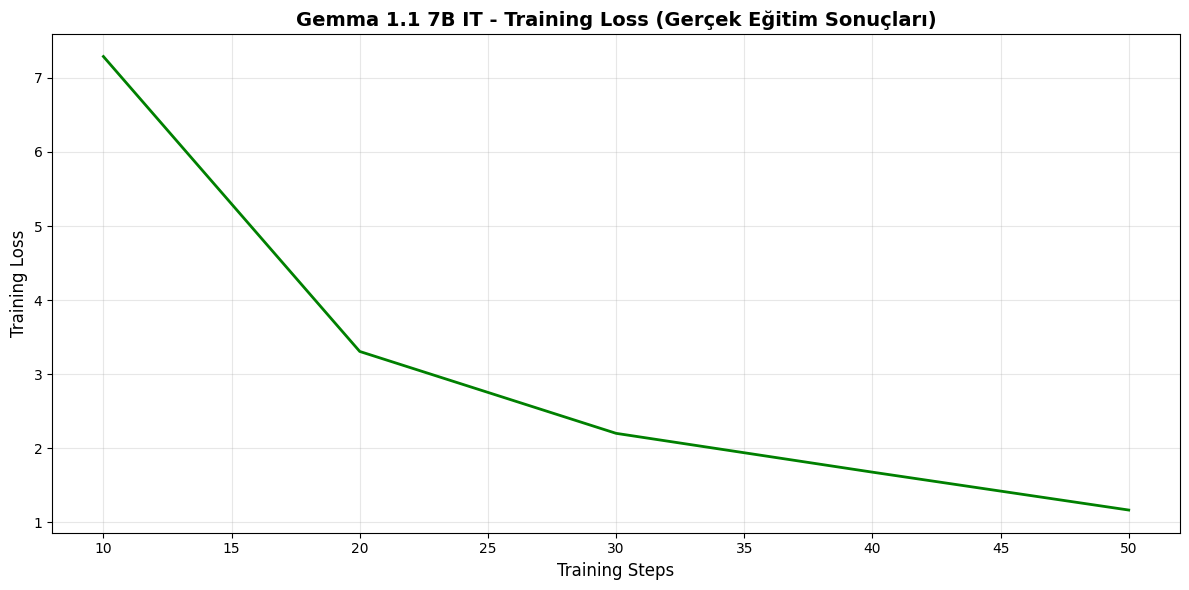


📈 Loss İstatistikleri:
- Başlangıç Loss: 7.2871
- Final Loss: 1.1680
- İyileşme: 83.97%
- Minimum Loss: 1.1680
- Maksimum Loss: 7.2871


In [10]:
# Training metriklerini görselleştir
print("📊 Training metriklerini çıkarıyorum...")

# Log history'den loss değerlerini al
log_history = trainer.state.log_history

steps = []
losses = []

for log in log_history:
    if 'loss' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

# Grafik oluştur
plt.figure(figsize=(12, 6))
plt.plot(steps, losses, linewidth=2, color='green')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Gemma 1.1 7B IT - Training Loss (Gerçek Eğitim Sonuçları)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/training_loss.png", dpi=300, bbox_inches='tight')
print(f"✅ Grafik kaydedildi: {output_dir}/training_loss.png")
plt.show()

# Loss istatistikleri
print(f"\n📈 Loss İstatistikleri:")
print(f"- Başlangıç Loss: {losses[0]:.4f}")
print(f"- Final Loss: {losses[-1]:.4f}")
print(f"- İyileşme: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")
print(f"- Minimum Loss: {min(losses):.4f}")
print(f"- Maksimum Loss: {max(losses):.4f}")

In [11]:
# Model ve tokenizer'ı kaydet
save_dir = "./gemma_medical_finetuned"

print(f"💾 Model kaydediliyor: {save_dir}")

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ Model kaydedildi: {save_dir}")
print(f"\n📦 Model Dosyaları:")
!ls -lh {save_dir}

# Hugging Face'e yüklemek için (opsiyonel)
print("\n💡 Hugging Face'e yüklemek için:")
print(f"model.push_to_hub('sizin-username/gemma-1.1-7b-medical-finetuned', token='hf_...')")
print(f"tokenizer.push_to_hub('sizin-username/gemma-1.1-7b-medical-finetuned', token='hf_...')")

💾 Model kaydediliyor: ./gemma_medical_finetuned
✅ Model kaydedildi: ./gemma_medical_finetuned

📦 Model Dosyaları:
total 228M
-rw-r--r-- 1 root root 1.2K Dec 20 08:45 adapter_config.json
-rw-r--r-- 1 root root 191M Dec 20 08:45 adapter_model.safetensors
-rw-r--r-- 1 root root  591 Dec 20 08:45 chat_template.jinja
-rw-r--r-- 1 root root 5.2K Dec 20 08:45 README.md
-rw-r--r-- 1 root root  636 Dec 20 08:45 special_tokens_map.json
-rw-r--r-- 1 root root  40K Dec 20 08:45 tokenizer_config.json
-rw-r--r-- 1 root root  33M Dec 20 08:45 tokenizer.json
-rw-r--r-- 1 root root 4.1M Dec 20 08:45 tokenizer.model

💡 Hugging Face'e yüklemek için:
model.push_to_hub('sizin-username/gemma-1.1-7b-medical-finetuned', token='hf_...')
tokenizer.push_to_hub('sizin-username/gemma-1.1-7b-medical-finetuned', token='hf_...')


In [12]:
# Test: Eğitilmiş modeli dene
print("🧪 Eğitilmiş modeli test ediyorum...\n")

FastLanguageModel.for_inference(model)

test_questions = [
    "What is hypertension and how is it treated?",
    "What are the symptoms of diabetes?",
    "How is pneumonia diagnosed?"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"❓ Test {i}: {question}")
    print(f"{'='*60}")

    # Gemma formatında prompt oluştur
    instruction = "Answer the question truthfully, you are a medical professional."
    prompt = f"<start_of_turn>user\n{instruction}\n{question}<end_of_turn>\n<start_of_turn>model\n"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Sadece model yanıtını göster
    answer = response.split("<start_of_turn>model")[-1].strip()
    print(f"\n💡 Yanıt:\n{answer}")

print("\n✅ Test tamamlandı!")

🧪 Eğitilmiş modeli test ediyorum...


❓ Test 1: What is hypertension and how is it treated?

💡 Yanıt:
user
Answer the question truthfully, you are a medical professional.
What is hypertension and how is it treated?
model
Hypertension (high blood pressure) is a condition in which the blood pressure in arteries is elevated. High blood pressure is a major risk factor for a variety of serious health conditions including heart attack, stroke, heart failure, kidney failure, and even death.
Symptoms of high blood pressure usually do not occur. The condition is often asymptomatic until complications develop. However, symptoms of high blood pressure that do occur can include: Headache Fatigue Dizziness Dizziness or lightheadedness Difficulty sleeping Sleep apnea (obstructive sleep apnea) Pain in the chest Pain in the abdomen 
Diagnosis of high blood pressure is done with a sphygmomanometer. This device measures blood pressure in the arm. A reading of 140/90 mmHg is considered to be high blood p

In [13]:
# GERÇEK MODEL KARŞILAŞTIRMASI
# Base model'i yükleyerek gerçek karşılaştırma yapalım

print("📊 BASE MODEL YÜKLENIYOR...")
print("="*60)

# Base model'i yükle
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-1.1-7b-it-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)
FastLanguageModel.for_inference(base_model)

print("✅ Base model yüklendi!\n")

# Test soruları
comparison_questions = [
    "What is hypertension?",
    "What are the symptoms of diabetes?",
    "How is asthma treated?"
]

print("🔬 KARŞILAŞTIRMA TESTİ")
print("="*60)

instruction = "Answer the question truthfully, you are a medical professional."

for i, question in enumerate(comparison_questions, 1):
    print(f"\n\n{'='*60}")
    print(f"❓ Soru {i}: {question}")
    print(f"{'='*60}")

    # Gemma formatında prompt
    prompt = f"<start_of_turn>user\n{instruction}\n{question}<end_of_turn>\n<start_of_turn>model\n"

    # BASE MODEL
    print("\n🔵 BASE MODEL (Eğitilmemiş):")
    print("-" * 60)
    inputs = base_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        eos_token_id=base_tokenizer.eos_token_id,
    )
    base_response = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
    base_answer = base_response.split("<start_of_turn>model")[-1].strip()
    print(base_answer)

    # FINE-TUNED MODEL
    print("\n\n🟢 FINE-TUNED MODEL (Eğitilmiş):")
    print("-" * 60)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
    )
    ft_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    ft_answer = ft_response.split("<start_of_turn>model")[-1].strip()
    print(ft_answer)

print("\n\n" + "="*60)
print("✅ KARŞILAŞTIRMA TAMAMLANDI!")
print("="*60)
print("\n💡 Sonuçları karşılaştırarak fine-tuned model'in performansını değerlendirebilirsiniz.")

📊 BASE MODEL YÜKLENIYOR...
==((====))==  Unsloth 2025.12.8: Fast Gemma patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Base model yüklendi!

🔬 KARŞILAŞTIRMA TESTİ


❓ Soru 1: What is hypertension?

🔵 BASE MODEL (Eğitilmemiş):
------------------------------------------------------------
user
Answer the question truthfully, you are a medical professional.
What is hypertension?
model
Hypertension, also known as high blood pressure, is a condition where the force of blood pushing against the walls of your blood vessels is abnormally high. This can increase the risk of serious health complications such as heart attack, stroke, kidney fail

In [14]:
# ÖZET RAPOR
print("\n" + "="*70)
print("📋 EĞİTİM ÖZET RAPORU")
print("="*70)

print(f"\n🎯 Model Bilgileri:")
print(f"  - Base Model: Gemma-1.1-7B-IT")
print(f"  - Fine-tuning Yöntemi: LoRA (r=16)")
print(f"  - Quantization: 4-bit")
print(f"  - Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

print(f"\n📚 Dataset:")
print(f"  - İsim: medical_llama3_instruct_dataset_short")
print(f"  - Örnek Sayısı: {len(dataset)}")
print(f"  - Alan: Tıbbi Soru-Cevap")
print(f"  - Format: Gemma chat format'a dönüştürüldü")

print(f"\n⚙️ Training Parametreleri:")
print(f"  - Batch Size: {training_args.per_device_train_batch_size}")
print(f"  - Gradient Accumulation: {training_args.gradient_accumulation_steps}")
print(f"  - Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning Rate: {training_args.learning_rate}")
print(f"  - Max Steps: {training_args.max_steps}")
print(f"  - Optimizer: {training_args.optim}")

print(f"\n📊 Eğitim Sonuçları:")
print(f"  - Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye ({trainer_stats.metrics['train_runtime']/60:.1f} dakika)")
print(f"  - Final Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"  - Başlangıç Loss: {losses[0]:.4f}")
print(f"  - Loss İyileşmesi: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

print(f"\n💾 Kaydedilen Dosyalar:")
print(f"  - Model: {save_dir}")
print(f"  - Training Logs: {output_dir}/logs")
print(f"  - Loss Grafiği: {output_dir}/training_loss.png")

print("\n" + "="*70)
print("🎉 TÜM İŞLEMLER TAMAMLANDI!")
print("="*70)
print("\n✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!")
print("✅ Gemma 1.1 7B IT modeli başarıyla fine-tune edildi ve kaydedildi.")
print("✅ Karşılaştırmalı test sonuçları gösterildi.")
print("\n💡 Modelinizi kullanmak için: model.push_to_hub() veya yerel olarak yükleyin.")


📋 EĞİTİM ÖZET RAPORU

🎯 Model Bilgileri:
  - Base Model: Gemma-1.1-7B-IT
  - Fine-tuning Yöntemi: LoRA (r=16)
  - Quantization: 4-bit
  - Eğitilebilir Parametreler: 50,003,968 (1.06%)

📚 Dataset:
  - İsim: medical_llama3_instruct_dataset_short
  - Örnek Sayısı: 50
  - Alan: Tıbbi Soru-Cevap
  - Format: Gemma chat format'a dönüştürüldü

⚙️ Training Parametreleri:
  - Batch Size: 2
  - Gradient Accumulation: 4
  - Efektif Batch Size: 8
  - Learning Rate: 0.0002
  - Max Steps: 50
  - Optimizer: OptimizerNames.ADAMW_8BIT

📊 Eğitim Sonuçları:
  - Toplam Süre: 410.47 saniye (6.8 dakika)
  - Final Loss: 3.1290
  - Başlangıç Loss: 7.2871
  - Loss İyileşmesi: 83.97%

💾 Kaydedilen Dosyalar:
  - Model: ./gemma_medical_finetuned
  - Training Logs: ./gemma_medical_output/logs
  - Loss Grafiği: ./gemma_medical_output/training_loss.png

🎉 TÜM İŞLEMLER TAMAMLANDI!

✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!
✅ Gemma 1.1 7B IT modeli başarıyla fine-tune edildi ve kaydedildi.
✅ 